In [14]:
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

import pulser
from pulser.waveforms import InterpolatedWaveform, CustomWaveform

import emu_sv
from emu_sv import SVConfig, SVBackend, Occupation, StateResult, StateVector, Fidelity

from pulse_counter_diabatic.counter_diabatic import CounterDiabaticPulse

from pulser import AnalogDevice

In [15]:
# ── DMRG ground-state helper ─────────────────────────────────────────────────
from emu_mps import (
    MPSBackend, MPSConfig, Solver, StateResult,
    Fidelity, Occupation, CorrelationMatrix, EntanglementEntropy, BitStrings
)

def dmrg_ground_state(seq):
    cfg = MPSConfig(with_modulation=False, dt=10, solver=Solver.DMRG, observables=[StateResult(evaluation_times=[1.0])])
    backend = MPSBackend(seq,config=cfg)
    result= backend.run() 
    target = result.final_state
    return target


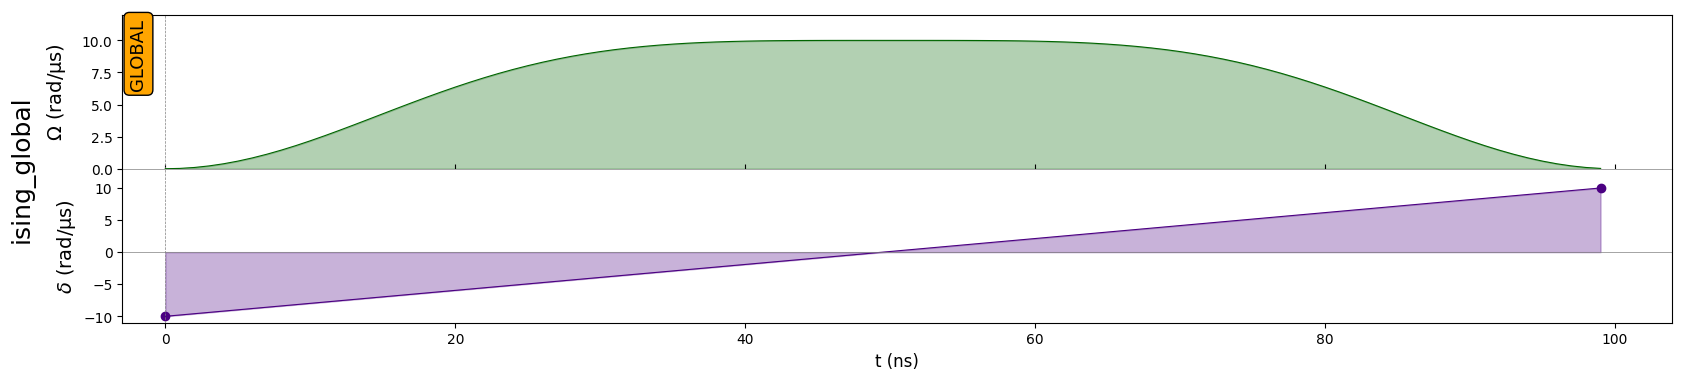

Atoms: 9
Duration: 100 ns,  dt: 1 ns,  steps: 100


In [24]:
n_side = 3
n_atoms = n_side * n_side
spacing = 7.0  

reg = pulser.Register.square(n_side, prefix="q", spacing=spacing)

# --- Bare adiabatic protocol ------------------------------------------------
# Ω(t) ≡ 0  →  pure detuning sweep
# δ(t) goes from -delta_max to +delta_max linearly
T = 100          # total duration in ns
dt = 1           # emulation timestep in ns
delta_max = 10.0  # rad/μs (Pulser convention)
omega_max = 10.0   # required by the problem statement
C6= AnalogDevice.interaction_coeff

pulse_times = np.arange(T)                              
omega_samples = omega_max * np.sin(0.5 * np.pi * np.sin(np.pi * pulse_times / T)) ** 2
omega_wf = CustomWaveform(omega_samples)
adiabatic_pulse = pulser.Pulse(
    omega_wf,         # Ω(t) = 0
    InterpolatedWaveform(T, [-delta_max, delta_max]),         # δ ramp
    0.0,
)

seq = pulser.Sequence(reg, pulser.MockDevice)
seq.declare_channel("ising_global", "rydberg_global")
seq.add(adiabatic_pulse, "ising_global")
seq.draw()
print(f"Atoms: {n_atoms}")
print(f"Duration: {T} ns,  dt: {dt} ns,  steps: {T // dt}")

In [25]:
target=dmrg_ground_state(seq)

emu-mps allows only {'energy', 'energy_variance', 'energy_second_moment', 'occupation', 'bitstrings', 'correlation_matrix', 'statistics'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'state'} using `optimize_qubit_ordering = False` instead.
emu-mps allows only {'energy', 'energy_variance', 'energy_second_moment', 'occupation', 'bitstrings', 'correlation_matrix', 'statistics'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'state'} using `optimize_qubit_ordering = False` instead.
step = 1/10, χ = 4, |ψ| = 0.003 MB, RSS = 11.710 MB, Δt = 0.209 s
step = 2/10, χ = 9, |ψ| = 0.009 MB, RSS = 11.736 MB, Δt = 0.281 s
step = 3/10, χ = 11, |ψ| = 0.011 MB, RSS = 11.745 MB, Δt = 0.278 s
step = 4/10, χ = 12, |ψ| = 0.013 MB, RSS = 11.752 MB, Δt = 0.266 s
step = 5/10, χ = 13, |ψ| = 0.015 MB, RSS = 11.760 MB, Δt = 0.248 s
step = 6/10, χ = 13, |ψ| = 0.015 MB, RSS = 11.760 MB, Δt = 0.261 s
step = 7/10, χ = 14, |ψ| = 0.016 MB, RSS = 11.766 MB, 

In [ ]:
config_for_cd = MPSConfig(dt=dt, observables=[])

# LCD only
cd_lcd = CounterDiabaticPulse(seq, config_for_cd)
seq_data_lcd = cd_lcd.solver(cold_fourier=0)

# COLD 
cd_cold = CounterDiabaticPulse(seq, config_for_cd)
seq_data_cold = cd_cold.solver(cold_fourier=3, nruns=100, lr=1e-2)

/home/vvitale/pulse_counter_diabatic/.venv/lib/python3.10/site-packages/emu_mps/mps_config.py:111: UserWarning: 'MPSConfig' was initialized without any observables. The corresponding emulation results will be empty.
  super().__init__(


LCD  loss = 4.415572e+03
step    0  loss = 4.415572e+03  ||β|| = 1.732e-02


/home/vvitale/pulse_counter_diabatic/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vvitale/pulse_counter_diabatic/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


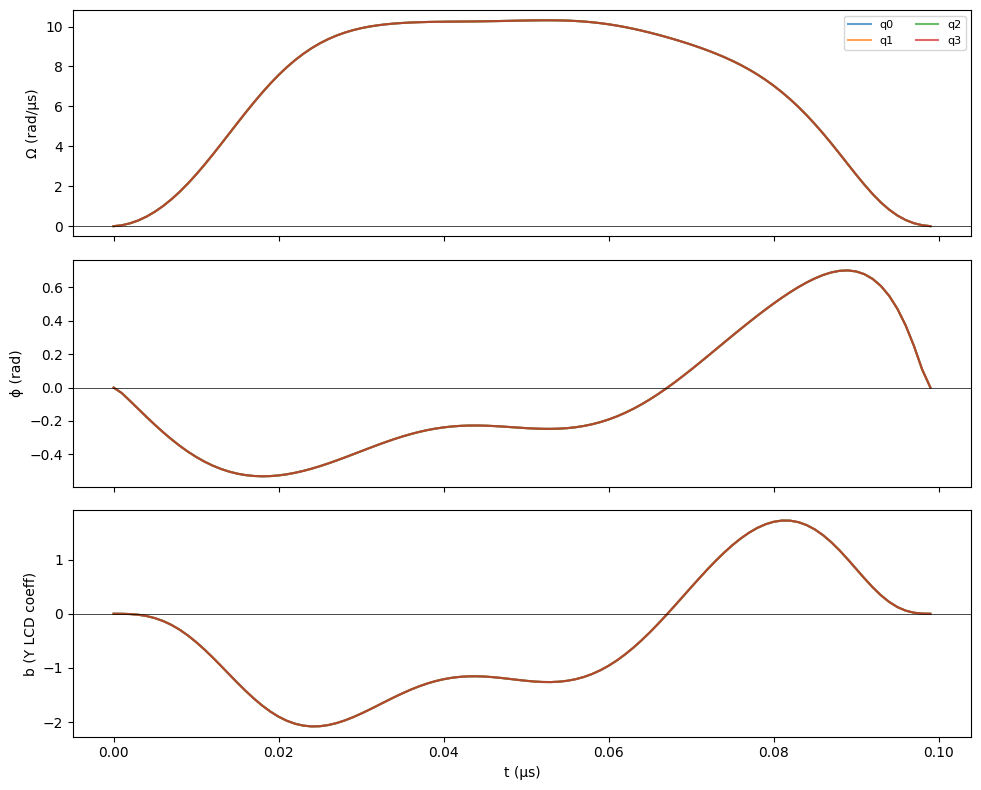

Ω(t=0)     = [0.00762738+0.j 0.00762738+0.j 0.00762738+0.j 0.00762738+0.j]
Ω(t=end)   = [0.00793224+0.j 0.00793224+0.j 0.00793224+0.j 0.00793224+0.j]
b(t=0)     = [-0. -0. -0. -0.]
b(t=end)   = [1.54626215e-32 1.54626215e-32 1.54626215e-32 1.54626215e-32]
ϕ(t=0)     = [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
ϕ(t=end)   = [3.89867896e-30+0.j 3.89867896e-30+0.j 3.89867896e-30+0.j
 3.89867896e-30+0.j]
Max |ϕ|    = 0.701080189543904
Max |Δϕ|   = 0.1415847968501021


In [ ]:
def to_np(t):
    return t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)

import numpy as np
import matplotlib.pyplot as plt

t = np.arange(seq_data_lcd.omega.shape[0]) * dt / 1000  # μs
omega_lcd = to_np(seq_data_lcd.omega)
phi_lcd   = to_np(seq_data_lcd.phi)
b_lcd     = to_np(cd_lcd.b_history)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i in range(n_atoms):
    axes[0].plot(t, omega_lcd[:, i], alpha=0.7, label=f"q{i}")
    axes[1].plot(t, phi_lcd[:, i],   alpha=0.7)
    axes[2].plot(t, b_lcd[:, i],     alpha=0.7)
axes[0].set_ylabel("Ω (rad/μs)")
axes[1].set_ylabel("ϕ (rad)")
axes[2].set_ylabel("b (Y LCD coeff)")
axes[2].set_xlabel("t (μs)")
axes[0].legend(ncol=2, fontsize=8)
for ax in axes:
    ax.axhline(0, color='k', lw=0.5)
fig.tight_layout()
plt.show()

# Specifically check endpoints
print(f"Ω(t=0)     = {omega_lcd[0]}")
print(f"Ω(t=end)   = {omega_lcd[-1]}")
print(f"b(t=0)     = {b_lcd[0]}")
print(f"b(t=end)   = {b_lcd[-1]}")
print(f"ϕ(t=0)     = {phi_lcd[0]}")
print(f"ϕ(t=end)   = {phi_lcd[-1]}")
print(f"Max |ϕ|    = {np.abs(phi_lcd).max()}")
print(f"Max |Δϕ|   = {np.abs(np.diff(phi_lcd, axis=0)).max()}")  # jumps?

In [ ]:
config = MPSConfig(
    dt=10,
    observables=[Fidelity(evaluation_times=[1.0], state=target),StateResult(evaluation_times=[1.0])])

print("Baseline schedule...")
backend = MPSBackend(seq, config=config)
results_baseline = backend.run()

emu-mps allows only {'energy', 'energy_variance', 'energy_second_moment', 'occupation', 'bitstrings', 'correlation_matrix', 'statistics'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'state', 'fidelity'} using `optimize_qubit_ordering = False` instead.
Baseline schedule...
emu-mps allows only {'energy', 'energy_variance', 'energy_second_moment', 'occupation', 'bitstrings', 'correlation_matrix', 'statistics'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'state', 'fidelity'} using `optimize_qubit_ordering = False` instead.
step = 1/10, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.027 s
step = 2/10, χ = 3, |ψ| = 0.001 MB, RSS = 11.691 MB, Δt = 0.039 s
step = 3/10, χ = 3, |ψ| = 0.001 MB, RSS = 11.691 MB, Δt = 0.049 s
step = 4/10, χ = 4, |ψ| = 0.001 MB, RSS = 11.691 MB, Δt = 0.048 s
step = 5/10, χ = 4, |ψ| = 0.001 MB, RSS = 11.691 MB, Δt = 0.048 s
step = 6/10, χ = 4, |ψ| = 0.001 MB, RSS = 11.691 MB, Δt = 0.048 s
step = 7/10, 

In [ ]:
print("Emulating LCD schedule...")
results_lcd=MPSBackend._run_from_sequence_data(seq_data_lcd, config)


Emulating LCD schedule...
step = 1/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.015 s
step = 2/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.013 s
step = 3/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.013 s
step = 4/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.014 s
step = 5/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.018 s


step = 6/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.021 s
step = 7/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.021 s
step = 8/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 9/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 10/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 11/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 12/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.022 s
step = 13/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 14/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.022 s
step = 15/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.021 s
step = 16/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.021 s
step = 17/100, χ = 2, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.022 s
step = 18/100, χ = 2, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.022 s
step = 19/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.691 MB, Δt = 0.028 s
step = 20/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.691 M

In [ ]:
print("Emulating COLD schedule...")
results_cold=MPSBackend._run_from_sequence_data(seq_data_cold, config)

Emulating COLD schedule...
step = 1/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.016 s
step = 2/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.013 s
step = 3/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.013 s
step = 4/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.014 s
step = 5/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.018 s
step = 6/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 7/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 8/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 9/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.021 s
step = 10/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 11/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 12/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 13/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.020 s
step = 14/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.691 MB, Δt = 0.021 s
step = 15/100, χ = 1, |ψ| = 0.

In [ ]:
fid_baseline = results_baseline.get_tagged_results()['fidelity']
fid_lcd  = results_lcd.get_tagged_results()['fidelity']
fid_cold = results_cold.get_tagged_results()['fidelity']

print(f"Baseline  ground-state fidelity: {fid_baseline}")
print(f"LCD  ground-state fidelity: {fid_lcd}")
print(f"COLD ground-state fidelity: {fid_cold}")

Baseline  ground-state fidelity: [tensor(0.0223, dtype=torch.float64)]
LCD  ground-state fidelity: [tensor(0.0259, dtype=torch.float64)]
COLD ground-state fidelity: [tensor(0.0253, dtype=torch.float64)]


In [ ]:
print("max |a| (X, should be ≈ 0):", cd_cold.a_history.abs().max().item())
print("max |b| (Y, the applied LCD):", cd_cold.b_history.abs().max().item())
print("max |c| (Z, should be ≈ 0):", cd_cold.c_history.abs().max().item())

max |a| (X, should be ≈ 0): 0.0
max |b| (Y, the applied LCD): 1.973417666154263
max |c| (Z, should be ≈ 0): 0.0
